In [1]:
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os
import sys
module_path = os.path.abspath(os.path.join('../../../../../'))
if module_path not in sys.path:
    sys.path.append(module_path)
    
from data_science_utilities.models.xgb.hyperparameter_search.random_search import OptimalXGBHyperparameterSearch

In [2]:
RANDOM_SEED = 32
# SELECTION_METRIC must match rfe.ipynb; it maps to the sklearn scoring name used for
# hyperparameter tuning so tuning optimizes the same objective as feature selection.
# BEST_NUM_FEATS (from rfe.ipynb's 1-SE output) and SELECTED_RFE_CSV are set per run.
SELECTION_METRIC = 'brier'
_SCORING = {'brier': 'neg_brier_score', 'roc_auc': 'roc_auc', 'log_loss': 'neg_log_loss'}[SELECTION_METRIC]
BEST_NUM_FEATS = 36
SELECTED_RFE_CSV = 'rfe_features_kfolds_brier.csv'
TARGET = 'target_win'

RANDOM_XGB_PARAMS = {
    'learning_rate': [.03, .05, .1, .15, .2],
    'max_depth': [2, 3],
    'subsample': [.5, .7, .9],
    'min_child_weight': [10, 20, 50, 100],
    'gamma': [.5, 1, 5, 10, 100],
    'n_estimators': [10, 20,30, 40, 50],
    'early_stopping_rounds': [10, 20, 50],
    'importance_type': ['total_gain'],
    'eval_metric': ['auc']
}

RANDOM_SEARCH_PARAMS = dict(
    n_iter=100,
    cv=5,
    n_jobs=-1,
    random_state=RANDOM_SEED,
    scoring=_SCORING,
)

BEST_FEATS_FROM_RFE = list(pd.read_csv(
    f'../../../../../data/predict_games/model_features_in/{SELECTED_RFE_CSV}',
    index_col=0
).loc[BEST_NUM_FEATS, :].dropna().values)

MODEL_INPUTS_DF = pd.read_parquet(
    '../../../../../data/predict_games/input_data/schedule_and_weekly.parquet'
)

MODEL_INPUTS_DF = MODEL_INPUTS_DF.sample(
    frac=1, random_state=RANDOM_SEED
).reset_index(drop=True)

np.random.seed(RANDOM_SEED)

In [3]:
# Two-season holdout: train on everything before 2022, use 2022-2023 as the early-stopping
# test slice, and hold out 2024+2025 (the original 3-way split shifted one year forward).
train_df = MODEL_INPUTS_DF[(MODEL_INPUTS_DF['season'] < 2022)]
test_df = MODEL_INPUTS_DF[
    (MODEL_INPUTS_DF['season'] >= 2022) & (MODEL_INPUTS_DF['season'] < 2024)
]
holdout_df = MODEL_INPUTS_DF[MODEL_INPUTS_DF['season'] >= 2024].copy()
X_train = train_df[BEST_FEATS_FROM_RFE]
y_train = train_df[TARGET]
X_test = test_df[BEST_FEATS_FROM_RFE]
y_test = test_df[TARGET]
X_holdout = holdout_df[BEST_FEATS_FROM_RFE]
y_holdout = holdout_df[TARGET]

In [4]:
rand_hyperparam_search = OptimalXGBHyperparameterSearch(
    X_train, y_train, X_test, y_test
)

In [5]:
rand_search = rand_hyperparam_search.search(
    RANDOM_XGB_PARAMS, **RANDOM_SEARCH_PARAMS
)

[0]	validation_0-auc:0.61874	validation_1-auc:0.60239
[1]	validation_0-auc:0.63409	validation_1-auc:0.61587
[2]	validation_0-auc:0.63396	validation_1-auc:0.61609
[0]	validation_0-auc:0.62655	validation_1-auc:0.60274
[3]	validation_0-auc:0.64908	validation_1-auc:0.63239
[4]	validation_0-auc:0.65832	validation_1-auc:0.63843
[0]	validation_0-auc:0.64089	validation_1-auc:0.62736
[1]	validation_0-auc:0.65701	validation_1-auc:0.62403
[5]	validation_0-auc:0.65874	validation_1-auc:0.64098
[1]	validation_0-auc:0.66571	validation_1-auc:0.63134
[2]	validation_0-auc:0.68211	validation_1-auc:0.64940
[6]	validation_0-auc:0.66151	validation_1-auc:0.64077
[2]	validation_0-auc:0.67837	validation_1-auc:0.64348
[7]	validation_0-auc:0.66458	validation_1-auc:0.64201
[3]	validation_0-auc:0.69099	validation_1-auc:0.65460
[3]	validation_0-auc:0.68750	validation_1-auc:0.65285
[8]	validation_0-auc:0.66582	validation_1-auc:0.64487
[4]	validation_0-auc:0.69058	validation_1-auc:0.65672
[4]	validation_0-auc:0.69476

[44]	validation_0-auc:0.69982	validation_1-auc:0.66039
[44]	validation_0-auc:0.70019	validation_1-auc:0.66137
[22]	validation_0-auc:0.72488	validation_1-auc:0.66662
[20]	validation_0-auc:0.72346	validation_1-auc:0.65975
[45]	validation_0-auc:0.70064	validation_1-auc:0.66139
[2]	validation_0-auc:0.68407	validation_1-auc:0.65666
[23]	validation_0-auc:0.72605	validation_1-auc:0.66720
[21]	validation_0-auc:0.72402	validation_1-auc:0.65972
[45]	validation_0-auc:0.70009	validation_1-auc:0.66010
[46]	validation_0-auc:0.70073	validation_1-auc:0.66144
[3]	validation_0-auc:0.69156	validation_1-auc:0.65733
[24]	validation_0-auc:0.72689	validation_1-auc:0.66660
[22]	validation_0-auc:0.72522	validation_1-auc:0.65937
[47]	validation_0-auc:0.70106	validation_1-auc:0.66150
[4]	validation_0-auc:0.69602	validation_1-auc:0.65992
[25]	validation_0-auc:0.72793	validation_1-auc:0.66532
[48]	validation_0-auc:0.70137	validation_1-auc:0.66174
[46]	validation_0-auc:0.70011	validation_1-auc:0.65956
[23]	validati

[40]	validation_0-auc:0.70501	validation_1-auc:0.66028
[2]	validation_0-auc:0.66211	validation_1-auc:0.65228
[9]	validation_0-auc:0.69424	validation_1-auc:0.66117
[29]	validation_0-auc:0.70181	validation_1-auc:0.66205
[41]	validation_0-auc:0.70492	validation_1-auc:0.66015
[26]	validation_0-auc:0.70021	validation_1-auc:0.65606
[3]	validation_0-auc:0.67059	validation_1-auc:0.64762
[48]	validation_0-auc:0.70539	validation_1-auc:0.65905
[42]	validation_0-auc:0.70545	validation_1-auc:0.66059
[30]	validation_0-auc:0.70203	validation_1-auc:0.66169
[27]	validation_0-auc:0.70075	validation_1-auc:0.65631
[49]	validation_0-auc:0.70574	validation_1-auc:0.65843
[43]	validation_0-auc:0.70559	validation_1-auc:0.66115
[31]	validation_0-auc:0.70229	validation_1-auc:0.66160
[0]	validation_0-auc:0.61376	validation_1-auc:0.57379
[0]	validation_0-auc:0.61790	validation_1-auc:0.58099
[28]	validation_0-auc:0.70163	validation_1-auc:0.65670
[0]	validation_0-auc:0.61373	validation_1-auc:0.58194
[4]	validation_0

[8]	validation_0-auc:0.66411	validation_1-auc:0.64795
[26]	validation_0-auc:0.65218	validation_1-auc:0.63134
[36]	validation_0-auc:0.65337	validation_1-auc:0.63645
[0]	validation_0-auc:0.60316	validation_1-auc:0.56609
[2]	validation_0-auc:0.62896	validation_1-auc:0.60607
[23]	validation_0-auc:0.70199	validation_1-auc:0.65579
[33]	validation_0-auc:0.65495	validation_1-auc:0.63567
[25]	validation_0-auc:0.70073	validation_1-auc:0.65685
[26]	validation_0-auc:0.70265	validation_1-auc:0.65556
[17]	validation_0-auc:0.69390	validation_1-auc:0.66096
[27]	validation_0-auc:0.65218	validation_1-auc:0.63134
[37]	validation_0-auc:0.65054	validation_1-auc:0.63147
[1]	validation_0-auc:0.62398	validation_1-auc:0.59057
[3]	validation_0-auc:0.62877	validation_1-auc:0.61312
[34]	validation_0-auc:0.65495	validation_1-auc:0.63567
[24]	validation_0-auc:0.70264	validation_1-auc:0.65499
[27]	validation_0-auc:0.70328	validation_1-auc:0.65603
[26]	validation_0-auc:0.70147	validation_1-auc:0.65773
[18]	validation

[21]	validation_0-auc:0.68618	validation_1-auc:0.65982
[23]	validation_0-auc:0.68432	validation_1-auc:0.66160
[8]	validation_0-auc:0.67664	validation_1-auc:0.64819
[37]	validation_0-auc:0.66870	validation_1-auc:0.64329
[24]	validation_0-auc:0.68710	validation_1-auc:0.65610
[25]	validation_0-auc:0.70441	validation_1-auc:0.66996
[24]	validation_0-auc:0.70305	validation_1-auc:0.66689
[22]	validation_0-auc:0.68653	validation_1-auc:0.65884
[9]	validation_0-auc:0.67461	validation_1-auc:0.64698
[24]	validation_0-auc:0.68477	validation_1-auc:0.66179
[38]	validation_0-auc:0.66876	validation_1-auc:0.64495
[25]	validation_0-auc:0.68799	validation_1-auc:0.65578
[26]	validation_0-auc:0.70495	validation_1-auc:0.66982
[25]	validation_0-auc:0.70385	validation_1-auc:0.66670
[25]	validation_0-auc:0.68544	validation_1-auc:0.66307
[39]	validation_0-auc:0.66876	validation_1-auc:0.64495
[10]	validation_0-auc:0.67482	validation_1-auc:0.64761
[26]	validation_0-auc:0.68846	validation_1-auc:0.65629
[27]	validat

...

[36]	validation_0-auc:0.71330	validation_1-auc:0.65989


[37]	validation_0-auc:0.71392	validation_1-auc:0.65950


[38]	validation_0-auc:0.71409	validation_1-auc:0.65945


[39]	validation_0-auc:0.71502	validation_1-auc:0.65903




Best parameters found:  {'subsample': 0.7, 'n_estimators': 40, 'min_child_weight': 20, 'max_depth': 2, 'learning_rate': 0.15, 'importance_type': 'total_gain', 'gamma': 10, 'eval_metric': 'auc', 'early_stopping_rounds': 50}


Best score found:  -0.22355408607025998


Best Selected Features:  ['off_target_sack_yards_cumulative_average_rank', 'is_home_target', 'off_opp_success_rate_competitive_ewma_average_rank', 'def_target_run_right_end_yards_per_attempt_garbage_trailing_ewma_average_rank', 'def_opp_down1_success_rate_pass_garbage_leading_rolling_average_rank', 'def_opp_run_right_end_yards_per_attempt_garbage_trailing_ewma_average_rank', 'off_opp_snap_share_garbage_leading_cumulative_average_rank', 'opp_def_cumulative_avg_points_allowed_rank', 'off_target_success_rate_competitive_ewma_average_rank', 'off_target_snap_share_garbage_leading_cumulative_average_rank', 'def_target_down2_med_success_rate_pass_garbage_leading_ewma_average_rank', 'opp_off_cumulative_avg_score_rank', 'off_opp_t

In [6]:
# view all the scores from the search
rand_search.cv_results_

{'mean_fit_time': array([0.18144102, 0.206672  , 0.17277665, 0.17421026, 0.21249347,
        0.07326317, 0.10133772, 0.09409246, 0.15747213, 0.15028963,
        0.07405667, 0.06758342, 0.16148839, 0.14388003, 0.17879419,
        0.11705022, 0.1023016 , 0.11160464, 0.09742498, 0.06595802,
        0.06976304, 0.09566188, 0.15997963, 0.13065825, 0.14101501,
        0.20359249, 0.09054418, 0.11028523, 0.16770654, 0.12426324,
        0.13064084, 0.2190268 , 0.09569683, 0.18725038, 0.07853093,
        0.08304014, 0.11576118, 0.153931  , 0.06999536, 0.10980964,
        0.18790798, 0.21392016, 0.09301577, 0.09471498, 0.14542232,
        0.06487479, 0.06779718, 0.09780436, 0.12859249, 0.1885643 ,
        0.14171448, 0.07136831, 0.23158174, 0.06168556, 0.20645261,
        0.1475234 , 0.29085779, 0.10319705, 0.2240798 , 0.10440245,
        0.17078838, 0.16700406, 0.07667756, 0.0871213 , 0.13674397,
        0.16930351, 0.11611352, 0.09362187, 0.14230604, 0.1978797 ,
        0.14501629, 0.11335192,

<Axes: >

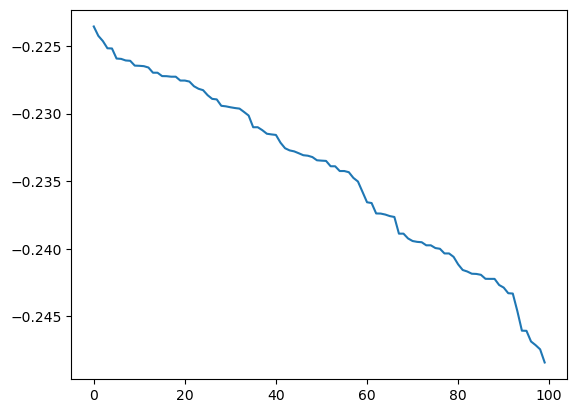

In [7]:
# Graph the search results. Make the index the rank of the score
# another column for the mean test score
rand_search_results = pd.DataFrame(rand_search.cv_results_)
rand_search_results['rank_test_score'] = rand_search_results['rank_test_score']
rand_search_results['mean_test_score'] = rand_search_results['mean_test_score']
rand_search_results = rand_search_results.sort_values(by='rank_test_score', ascending=True)
rand_search_results = rand_search_results.reset_index(drop=True)
rand_search_results['mean_test_score'].plot()

In [8]:
# What are the grid search params for the top 5 scores?
rand_search_results.head(5)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_subsample,param_n_estimators,param_min_child_weight,param_max_depth,param_learning_rate,param_importance_type,...,param_early_stopping_rounds,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.161424,0.008574,0.001923,0.000027,0.7,40,20,2,0.15,total_gain,...,50,"{'subsample': 0.7, 'n_estimators': 40, 'min_ch...",-0.223926,-0.224886,-0.225613,-0.222679,-0.220667,-0.223554,0.001747,1
1,0.231582,0.041722,0.003845,0.002518,0.5,50,50,2,0.15,total_gain,...,50,"{'subsample': 0.5, 'n_estimators': 50, 'min_ch...",-0.228700,-0.226027,-0.224695,-0.221982,-0.219828,-0.224246,0.003094,2
2,0.212493,0.029872,0.002048,0.000102,0.7,50,100,2,0.1,total_gain,...,50,"{'subsample': 0.7, 'n_estimators': 50, 'min_ch...",-0.224209,-0.224590,-0.230243,-0.223537,-0.220593,-0.224634,0.003136,3
3,0.160623,0.028589,0.002877,0.001265,0.7,40,100,3,0.2,total_gain,...,20,"{'subsample': 0.7, 'n_estimators': 40, 'min_ch...",-0.225229,-0.226216,-0.231273,-0.223304,-0.219814,-0.225167,0.003755,4
4,0.290858,0.018793,0.004964,0.004538,0.5,50,50,3,0.1,total_gain,...,50,"{'subsample': 0.5, 'n_estimators': 50, 'min_ch...",-0.229351,-0.225089,-0.229178,-0.223116,-0.219181,-0.225183,0.003838,5


In [9]:
# save the json of the best model
best_model = rand_search.best_estimator_
best_model.save_model(
    os.path.join(module_path, 'models', 'best_random_xgb_model.json')
)

In [10]:
# What is the score on the holdout set?
best_model.score(X_holdout, y_holdout)

0.6268382352941176

In [11]:
holdout_df.loc[:, 'preds'] = best_model.predict_proba(X_holdout)[:, 1]

In [12]:
# Single overall hold-out AUROC, computed exactly like bart.ipynb, reported alongside
# Brier/log-loss so every run is comparable on all axes regardless of selection metric.
overall_holdout_auroc = roc_auc_score(holdout_df['target_win'], holdout_df['preds'])
print(f'2024+2025 hold-out ROC-AUC (overall): {overall_holdout_auroc:.4f}  '
      f'[{BEST_NUM_FEATS} features, {SELECTED_RFE_CSV}, selected on {SELECTION_METRIC}]')

2024+2025 hold-out ROC-AUC (overall): 0.6926  [36 features, rfe_features_kfolds_brier.csv, selected on brier]


In [13]:
# Show the predictions for the holdout set
results_df = holdout_df[
    ['game_id', 'week', 'target_team', 'opp_team', 'target_win', 'preds']
].copy()
results_df.sort_values(by='game_id', inplace=True)
results_df.reset_index(drop=True, inplace=True)
results_df

,game_id,week,target_team,opp_team,target_win,preds
0,2024_01_ARI_BUF,1,ARI,BUF,0,0.390045
1,2024_01_ARI_BUF,1,BUF,ARI,1,0.623601
2,2024_01_BAL_KC,1,KC,BAL,1,0.514940
3,2024_01_BAL_KC,1,BAL,KC,0,0.451462
4,2024_01_CAR_NO,1,CAR,NO,0,0.401095
...,...,...,...,...,...,...
1083,2025_18_SEA_SF,18,SF,SEA,0,0.488741
1084,2025_18_TEN_JAX,18,JAX,TEN,1,0.623601
1085,2025_18_TEN_JAX,18,TEN,JAX,0,0.370172
1086,2025_18_WAS_PHI,18,PHI,WAS,0,0.599575


week
1     0.921875
2     0.530273
3     0.583496
4     0.576660
5     0.416454
6     0.630797
7     0.788889
8     0.662901
9     0.659929
10    0.736607
11    0.766944
12    0.775720
13    0.747559
14    0.722222
15    0.796875
16    0.736816
17    0.707520
18    0.628418
dtype: float64

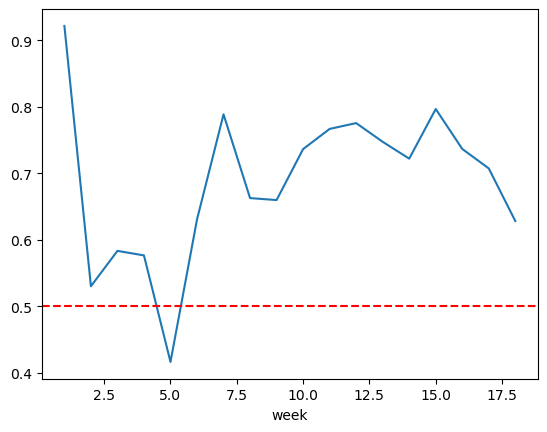

In [14]:
# get the AUROC score by week
weekly_scores = holdout_df.groupby('week').apply(
    lambda x: roc_auc_score(x['target_win'], x['preds']),
    include_groups=False
)
weekly_scores.plot()
# Place a horizontal line at .5 to show the baseline
plt.axhline(y=.5, color='r', linestyle='--')
weekly_scores

In [15]:
# for each game_id, only keep the higher prediction
higher_preds = holdout_df.groupby('game_id').apply(
    lambda x: x.loc[x['preds'].idxmax(), :],
    include_groups=False
)
higher_preds.reset_index(drop=True, inplace=True)

week
1     0.597701
2     0.615686
3     0.613725
4     0.581349
5     0.408163
6     0.663462
7     0.693182
8     0.694712
9     0.632353
10    0.506250
11    0.726316
12    0.610714
13    0.731250
14    0.434211
15    0.666667
16    0.769231
17    0.504545
18    0.495833
dtype: float64

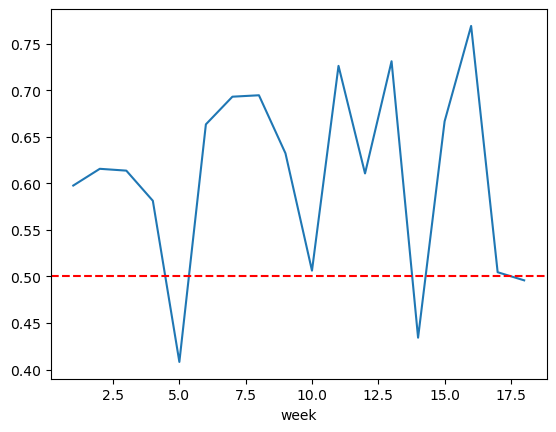

In [16]:
# get the AUROC score by week
weekly_scores = higher_preds.groupby('week').apply(
    lambda x: roc_auc_score(x['target_win'], x['preds']),
    include_groups=False
)
weekly_scores.plot()
# Place a horizontal line at .5 to show the baseline
plt.axhline(y=.5, color='r', linestyle='--')
weekly_scores

## How good are the model's *confident* predictions?

AUROC only measures **ranking** (can the model sort winners above losers?). It says
nothing about whether a 0.80 prediction is actually right ~80% of the time. The cells
below answer "when the model has a strong prediction, how well does it predict?" using:

1. **Brier score & log loss** — residual-based metrics that penalize overconfidence.
2. **Confidence-bucketed accuracy** — the direct answer: how often the favored team wins,
   grouped by how sure the model was.
3. **Reliability diagram** — visual calibration check (predicted prob vs observed win rate).

Note: `holdout_df` has two rows per `game_id` (one per team). Brier/log loss are computed
on all rows consistently; the bucketed-accuracy table uses the one-row-per-game `higher_preds`
frame so each game is counted once.

In [17]:
# Residual-based metrics. Unlike AUROC, these penalize confident-and-wrong predictions.
from sklearn.metrics import brier_score_loss, log_loss

brier = brier_score_loss(holdout_df['target_win'], holdout_df['preds'])
ll = log_loss(holdout_df['target_win'], holdout_df['preds'])
print(f"Brier score: {brier:.4f}  (lower is better; 0.25 = coin flip)")
print(f"Log loss:    {ll:.4f}  (lower is better; punishes confident-and-wrong hardest)")

Brier score: 0.2321  (lower is better; 0.25 = coin flip)
Log loss:    0.6569  (lower is better; punishes confident-and-wrong hardest)


In [18]:
# Confidence-bucketed accuracy: the direct answer to "when the model is confident, is it right?"
# On higher_preds, `preds` is the model's confidence in its pick (0.5-1.0) and
# target_win == 1 means the favored team actually won.
higher_preds['confidence'] = higher_preds['preds']
higher_preds['bucket'] = pd.cut(
    higher_preds['confidence'], bins=[0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
)

confidence_summary = higher_preds.groupby('bucket', observed=True).agg(
    n_games=('target_win', 'size'),
    pick_accuracy=('target_win', 'mean'),   # how often the favored team won
    avg_confidence=('confidence', 'mean'),  # what the model claimed
)
# Positive gap = overconfident (claimed more than it delivered)
confidence_summary['calibration_gap'] = (
    confidence_summary['avg_confidence'] - confidence_summary['pick_accuracy']
)
confidence_summary

,n_games,pick_accuracy,avg_confidence,calibration_gap
bucket,,,,
"(0.5, 0.6]",436,0.614679,0.549937,-0.064742
"(0.6, 0.7]",66,0.848485,0.620165,-0.228320


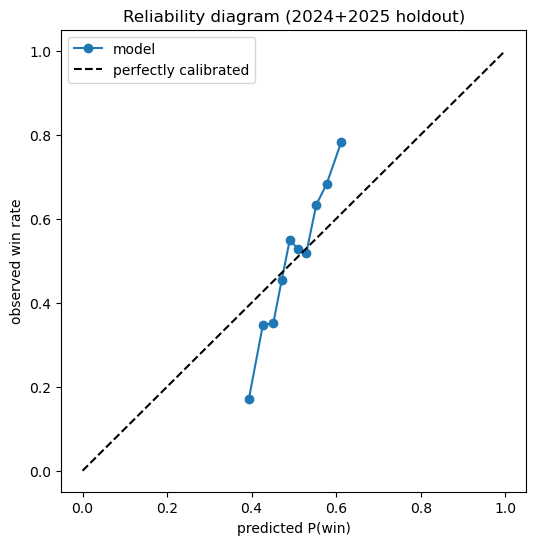

In [19]:
# Reliability diagram: are the probabilities trustworthy?
# Points on the diagonal = perfectly calibrated. Below the diagonal on the right
# side = the model is overconfident when bullish.
from sklearn.calibration import calibration_curve

prob_true, prob_pred = calibration_curve(
    holdout_df['target_win'], holdout_df['preds'], n_bins=10, strategy='quantile'
)
plt.figure(figsize=(6, 6))
plt.plot(prob_pred, prob_true, marker='o', label='model')
plt.plot([0, 1], [0, 1], 'k--', label='perfectly calibrated')
plt.xlabel('predicted P(win)')
plt.ylabel('observed win rate')
plt.title('Reliability diagram (2024+2025 holdout)')
plt.legend()
plt.show()

## Does a wider home-vs-away gap mean better predictions?

Each game has two predictions: `P(home wins)` from the home-perspective row and
`P(away wins)` from the away-perspective row. The **gap** between them is a stronger
confidence signal than `max(pred)` alone — it uses *both* perspectives. A wide gap
means the two views agree strongly on a winner; a narrow gap means the model is torn.

Hypothesis: when the gap is wide, accuracy should be higher. We pivot the two rows onto
one row per game (via `is_home_target`), define the model's pick as whichever side has
the higher probability, and bucket accuracy by gap width (quintiles, so every bin is
populated).

In [20]:
# Pivot the two perspectives of each game onto one row (is_home_target: 1 = home, 0 = away)
game_view = holdout_df.pivot_table(
    index='game_id', columns='is_home_target', values=['preds', 'target_win'], aggfunc='first'
).dropna()

games = pd.DataFrame({
    'home_pred': game_view[('preds', 1)],
    'away_pred': game_view[('preds', 0)],
    'home_won':  game_view[('target_win', 1)].astype(int),
})
games['gap']           = games['home_pred'] - games['away_pred']   # >0 leans home, <0 leans away
games['abs_gap']       = games['gap'].abs()                        # strength of the lean
games['pred_home_win'] = games['home_pred'] > games['away_pred']
games['correct']       = games['pred_home_win'] == (games['home_won'] == 1)

# Bucket by gap width (quintiles) and measure accuracy in each
games['gap_quintile'] = pd.qcut(games['abs_gap'], 5)
gap_summary = games.groupby('gap_quintile', observed=True).agg(
    n_games=('correct', 'size'),
    mean_abs_gap=('abs_gap', 'mean'),
    accuracy=('correct', 'mean'),
)
print(f"Overall correlation(abs_gap, correct): {games['abs_gap'].corr(games['correct'].astype(int)):.3f}")
gap_summary

Overall correlation(abs_gap, correct): 0.229


,n_games,mean_abs_gap,accuracy
gap_quintile,,,
"(-0.00099514, 0.0357]",109,0.017206,0.504587
"(0.0357, 0.0735]",109,0.053310,0.605505
"(0.0735, 0.122]",109,0.100038,0.596330
"(0.122, 0.177]",109,0.147446,0.651376
"(0.177, 0.253]",108,0.211953,0.824074


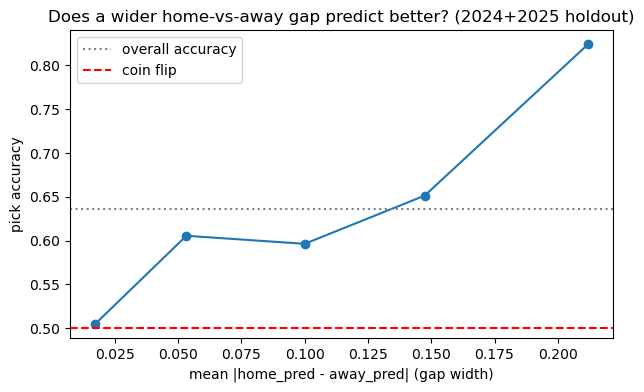

In [21]:
# Visualize the hypothesis: accuracy should rise as the home-vs-away gap widens
plt.figure(figsize=(7, 4))
plt.plot(gap_summary['mean_abs_gap'], gap_summary['accuracy'], marker='o')
plt.axhline(y=games['correct'].mean(), color='gray', linestyle=':', label='overall accuracy')
plt.axhline(y=0.5, color='r', linestyle='--', label='coin flip')
plt.xlabel('mean |home_pred - away_pred| (gap width)')
plt.ylabel('pick accuracy')
plt.title('Does a wider home-vs-away gap predict better? (2024+2025 holdout)')
plt.legend()
plt.show()